## Packages Installation

In [2]:
%pip install spacy
%pip install nltk  
## the above command for nltk only installs the package partially, so to have all features, nltk.download("all")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import nltk
import spacy 
nltk.download("all")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |

True

## Data Importing

In [4]:
twitter_data=pd.read_csv("https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/Twitter_Sentiment/Twitter_Sentiment_Data.csv")
twitter_data.sample(10)

,tweet_ID,raw_tweet,sentiment_label
6143,d056c086ec,Burning my tongue on Won Ton soup,neutral
18061,17b79b96b8,You be a good girl Whitney,positive
21669,378a968849,i am listening this song 'shattered' by Tynish...,neutral
18151,af8106f972,http://twitpic.com/67jzp McFly concerts throug...,neutral
11905,9f0e28a438,to start **** or leave **** alone...tough deci...,negative
4684,de5afb99a6,Sorry if I`m unsociable I`m loading up stock i...,neutral
16224,d1d317ef0e,sick of having constant bad dreams grr,negative
10060,01879ae972,Swiped the last package of fruit snacks! Hell ...,negative
22945,683e701314,"I`ve had for a while now, just in case. And ...",positive
7356,01c07eb814,i dont noe what to eat for breakfast hmmmmmmm ...,neutral


## Lower Case Conversion

In [5]:
twitter_data["tweet_lowcase"]=twitter_data["raw_tweet"].apply(lambda x:str(x).lower())   
#lambda function to apply on all rows
# str(x) is used to avoid errors due to NaN and numeric values

twitter_data.sample(10)

,tweet_ID,raw_tweet,sentiment_label,tweet_lowcase
26965,5e820a039e,It is going to be a beautiful day!,positive,it is going to be a beautiful day!
15044,85ed4ae17e,Headin home...Refreshed my mind and soul justa...,positive,headin home...refreshed my mind and soul justa...
23210,e5b77c7f4f,http://twitpic.com/4wsst - one of my models fr...,neutral,http://twitpic.com/4wsst - one of my models fr...
8542,7a69ae6162,BBQ`s gone well ! Weather stayed good which is...,neutral,bbq`s gone well ! weather stayed good which is...
22592,c3c1abb017,trying to find some friends and not having any...,negative,trying to find some friends and not having any...
23420,8a088af6b1,"i`m having tuna & noodles thing, smashed pot...",neutral,"i`m having tuna & noodles thing, smashed pot..."
12409,f4e5e417d7,mmm nandos is good (y) and topshop rules i am...,negative,mmm nandos is good (y) and topshop rules i am...
8744,8a999026ad,Charlie Brown What are you doing today? What...,neutral,charlie brown what are you doing today? what...
12713,cee4eb7282,i`m not worried -it`s a great job!! Quite a n...,positive,i`m not worried -it`s a great job!! quite a n...
3754,a891fa0eea,thanks lady.... bummer for sure.,positive,thanks lady.... bummer for sure.


## Tokenizing

In [6]:
from nltk.tokenize import word_tokenize
twitter_data["word_tokens"] = twitter_data["tweet_lowcase"].apply(lambda x:word_tokenize(str(x)))  
# data in word_tokens column will be in list format because the word_tokenize function returns list [one tweet -> many words -> list is necessary]
#lambda function to apply on all rows
#str() function to avoid numeric and other errors

twitter_data[["raw_tweet","word_tokens"]].sample(10)

,raw_tweet,word_tokens
26669,#myweakness too loving ...i always let negativ...,"[#, myweakness, too, loving, ..., i, always, l..."
10067,Nothing 2 do 2nte Boooooooo! I`m totally bored!,"[nothing, 2, do, 2nte, boooooooo, !, i, `, m, ..."
8147,"I think they`re really good, so that probably...","[i, think, they, `, re, really, good, ,, so, t..."
21774,its raining! boo,"[its, raining, !, boo]"
19960,listenin do da beach girl5 on itunes,"[listenin, do, da, beach, girl5, on, itunes]"
18381,Feelin really awful. Having mono sux so much. ...,"[feelin, really, awful, ., having, mono, sux, ..."
10111,Loves her david soooooo much <3,"[loves, her, david, soooooo, much, <, 3]"
20860,just got my BMTH concert tickets ? youknowims...,"[just, got, my, bmth, concert, tickets, ?, you..."
12887,. ... and now I wish I hadn`t,"[., ..., and, now, i, wish, i, hadn, `, t]"
4773,"Omg. I am so sorry. Sorry, I never know what ...","[omg, ., i, am, so, sorry, ., sorry, ,, i, nev..."


## Expanding shortforms

In [7]:
contra_Expan_Dict = {"ain`t": "am not","aren`t": "are not","can`t": "cannot","can`t`ve": "cannot have","`cause": "because",
"could`ve": "could have","couldn`t": "could not","couldn`t`ve": "could not have","didn`t": "did not",
"doesn`t": "does not","don`t": "do not","hadn`t": "had not","hadn`t`ve": "had not have","hasn`t": "has not",
"haven`t": "have not","he`d": "he would","he`d`ve": "he would have","he`ll": "he will","he`ll`ve": "he will have",
"he`s": "he is","how`d": "how did","how`d`y": "how do you","how`ll": "how will",
"how`s": "how does","i`d": "i would","i`d`ve": "i would have","i`ll": "i will","i`ll`ve": "i will have","i`m": "i am",
"i`ve": "i have","isn`t": "is not","it`d": "it would","it`d`ve": "it would have","it`ll": "it will","it`ll`ve": "it will have",
"it`s": "it is","let`s": "let us","ma`am": "madam","mayn`t": "may not","might`ve": "might have","mightn`t": "might not",
"mightn`t`ve": "might not have","must`ve": "must have","mustn`t": "must not","mustn`t`ve": "must not have","needn`t": "need not","needn`t`ve": "need not have",
"o`clock": "of the clock","oughtn`t": "ought not","oughtn`t`ve": "ought not have","shan`t": "shall not",
"sha`n`t": "shall not","shan`t`ve": "shall not have","she`d": "she would",
"she`d`ve": "she would have","she`ll": "she will","she`ll`ve": "she will have",
"she`s": "she is","should`ve": "should have","shouldn`t": "should not","shouldn`t`ve": "should not have","so`ve": "so have","so`s": "so is",
"that`d": "that would","that`d`ve": "that would have","that`s": "that is","there`d": "there would","there`d`ve": "there would have","there`s": "there is",
"they`d": "they would","they`d`ve": "they would have","they`ll": "they will","they`ll`ve": "they will have","they`re": "they are","they`ve": "they have",
"to`ve": "to have","wasn`t": "was not"," u ": " you "," ur ": " your "," n ": " and ","won`t": "would not",
"dis": "this","bak": "back","brng": "bring"}

In [8]:
# the function checks word in the above dict and replaces it with it's expanded form if present otherwise keeps the word as it is
def expanded_form(x):
    if x in contra_Expan_Dict.keys():
        return(contra_Expan_Dict[x])
    else:
        return(x)

In [9]:
# Application of the above function on a sample tweet
x=str(twitter_data["tweet_lowcase"][6207])
print("original tweet ==>", x)
x=x.split()
print(x)
print("Expanded form ==>",[expanded_form(t) for t in x])

original tweet ==>  it`s under a honeymoon by the good life
['it`s', 'under', 'a', 'honeymoon', 'by', 'the', 'good', 'life']
Expanded form ==> ['it is', 'under', 'a', 'honeymoon', 'by', 'the', 'good', 'life']


In [10]:
twitter_data["tweet_expanded"]=twitter_data["tweet_lowcase"].apply(lambda x:[expanded_form(t) for t in str(x).split()])
twitter_data[["raw_tweet","tweet_expanded"]].sample(10)

,raw_tweet,tweet_expanded
2710,on my 42nd written ****.. i get less ideas eve...,"[on, my, 42nd, written, ****.., i, get, less, ..."
19253,Download movie 'Ben 10: Alien Force' http://t...,"[download, movie, 'ben, 10:, alien, force', ht..."
24966,you looked great for being sick yesterday! i`...,"[you, looked, great, for, being, sick, yesterd..."
24052,jb are so cute! lmfao -giggles-,"[jb, are, so, cute!, lmfao, -giggles-]"
23642,feeling better. drugs are awesome! sad waste o...,"[feeling, better., drugs, are, awesome!, sad, ..."
3677,no one calls me anymore,"[no, one, calls, me, anymore]"
4978,hey Samantha welcome and happy mother`s day!!,"[hey, samantha, welcome, and, happy, mother`s,..."
6530,thanks for following! pretty complicated id...,"[thanks, for, following!, pretty, complicated,..."
10211,I miss all you OK girls. Happy Mother`s D...,"[i, miss, all, you, ok, girls., happy, mother`..."
8085,I`m bummed...you`re gonna be only 30 minutes ...,"[i am, bummed...you`re, gonna, be, only, 30, m..."


## Stopwords Removal

### NLTK Stopwords

In [11]:
from nltk.corpus import stopwords
nltk_stop_words = set(stopwords.words('english')) ##Selecting the stop words from the Language
print("Number of Stop words in NLTK ==>", len(nltk_stop_words))
print(sorted(nltk_stop_words))

Number of Stop words in NLTK ==> 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're'

In [12]:
twitter_data["After_Removing_Stopwords_nltk"] = twitter_data["tweet_expanded"].apply(lambda x:[t for t in x if t not in nltk_stop_words ])
twitter_data[["raw_tweet","After_Removing_Stopwords_nltk"]].sample(10)

,raw_tweet,After_Removing_Stopwords_nltk
5746,Oh no! My kindergarten teacher died Mrs. Coll...,"[oh, no!, kindergarten, teacher, died, mrs., c..."
15341,Getting ready for school - second maths test t...,"[getting, ready, school, -, second, maths, tes..."
13933,happy mothers day @ my mum (also to my sis a...,"[happy, mothers, day, @, mum, (also, sis, 'mum..."
16471,yeah ... he was 0-3 and SCOREless tonight,"[yeah, ..., 0-3, scoreless, tonight]"
3640,Sitting in an empty yearbook room. attempting...,"[sitting, empty, yearbook, room., attempting, ..."
7770,Exhausted after a 58 hour work week,"[exhausted, 58, hour, work, week]"
8207,Thank you Google for your Adsense Payment. If...,"[thank, google, adsense, payment., aussie, dol..."
25430,"#NHL Not a fan of either team, my head says De...","[#nhl, fan, either, team,, head, says, detroit..."
25191,has spent the last two weeks attempting to gro...,"[spent, last, two, weeks, attempting, grow, be..."
11359,Cool. You should qik some stuff from the news...,"[cool., qik, stuff, newsroom, sometime., lol.]"


### spaCy Stopwords

In [13]:
from spacy.lang.en.stop_words import STOP_WORDS as spacy_stopwords
print("Number of Stop words in spaCy ==>", len(spacy_stopwords))
print(sorted(spacy_stopwords))
#Spacy stopwords list looks better.

Number of Stop words in spaCy ==> 326
["'d", "'ll", "'m", "'re", "'s", "'ve", 'a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost', 'alone', 'along', 'already', 'also', 'although', 'always', 'am', 'among', 'amongst', 'amount', 'an', 'and', 'another', 'any', 'anyhow', 'anyone', 'anything', 'anyway', 'anywhere', 'are', 'around', 'as', 'at', 'back', 'be', 'became', 'because', 'become', 'becomes', 'becoming', 'been', 'before', 'beforehand', 'behind', 'being', 'below', 'beside', 'besides', 'between', 'beyond', 'both', 'bottom', 'but', 'by', 'ca', 'call', 'can', 'cannot', 'could', 'did', 'do', 'does', 'doing', 'done', 'down', 'due', 'during', 'each', 'eight', 'either', 'eleven', 'else', 'elsewhere', 'empty', 'enough', 'even', 'ever', 'every', 'everyone', 'everything', 'everywhere', 'except', 'few', 'fifteen', 'fifty', 'first', 'five', 'for', 'former', 'formerly', 'forty', 'four', 'from', 'front', 'full', 'further', 'get', 'give', 'go', 'had', 'has', 'ha

In [14]:
# example of removing stopwords using spacy stopwords list
x= ['i', 'saw', 'it', 'the', 'moive', 'is', 'pathetic']
print("original tweet ==>", x)
print("After Removing Stopwords ==>",[t for t in x if t not in spacy_stopwords])

original tweet ==> ['i', 'saw', 'it', 'the', 'moive', 'is', 'pathetic']
After Removing Stopwords ==> ['saw', 'moive', 'pathetic']


In [15]:
twitter_data["After_Removing_Stopwords"] = twitter_data["tweet_expanded"].apply(lambda x:[t for t in x if t not in spacy_stopwords ])
twitter_data[["raw_tweet","After_Removing_Stopwords"]].sample(10)

,raw_tweet,After_Removing_Stopwords
10938,has a face mask on. hehe,"[face, mask, on., hehe]"
9453,Alough I will hold you to your word now for w...,"[alough, hold, word, need, rain]"
14867,"Is in the badbooks again, don`t know why I bother","[badbooks, again,, do not, know, bother]"
23693,the there`s confuse me,"[there is, confuse]"
25575,Sad to be leaving so soon,"[sad, leaving, soon]"
25342,madd bored,"[madd, bored]"
22356,recovering from a hard day of homeschooling my...,"[recovering, hard, day, homeschooling, dd,, ch..."
17447,"I got a text from this guy who I don`t like, a...","[got, text, guy, do not, like,, guy, do!, disa..."
10388,Very. I`m ill and attempting to remember lots...,"[very., i am, ill, attempting, remember, lots,..."
14346,what happened to all your sexy quotes?,"[happened, sexy, quotes?]"


In [16]:
# comparing the output after removing stopwords 
twitter_data[["raw_tweet","tweet_expanded","After_Removing_Stopwords"]].sample(10)

,raw_tweet,tweet_expanded,After_Removing_Stopwords
22683,just woke up...feelin a lil better <3,"[just, woke, up...feelin, a, lil, better, <3]","[woke, up...feelin, lil, better, <3]"
2385,Must be time of month: Watering eyes AGAIN!: h...,"[must, be, time, of, month:, watering, eyes, a...","[time, month:, watering, eyes, again!:, http:/..."
16885,Back from x-men origins . Was surprisingly good,"[back, from, x-men, origins, ., was, surprisin...","[x-men, origins, ., surprisingly, good]"
1926,Your window ledge is decorated quite appropri...,"[your, window, ledge, is, decorated, quite, ap...","[window, ledge, decorated, appropriately., love]"
11982,"Just joined, no one is following me","[just, joined,, no, one, is, following, me]","[joined,, following]"
14096,Q: what studio created `Open Season`? should g...,"[q:, what, studio, created, `open, season`?, s...","[q:, studio, created, `open, season`?, google,..."
3837,LoL! there u go..that`s the spirit haha,"[lol!, there, u, go..that`s, the, spirit, haha]","[lol!, u, go..that`s, spirit, haha]"
14328,AC getting installed today,"[ac, getting, installed, today]","[ac, getting, installed, today]"
1189,"@ Little_Ren is lovely lovely, and so niceee","[@, little_ren, is, lovely, lovely,, and, so, ...","[@, little_ren, lovely, lovely,, niceee]"
21967,Happy Mother`s day; God bless you & all mother...,"[happy, mother`s, day;, god, bless, you, &, al...","[happy, mother`s, day;, god, bless, &, mother`..."


### Add Custom Stowords

In [17]:
from spacy.lang.en.stop_words import STOP_WORDS as spacy_stopwords
spacy_stopwords.update({"would", "rt","like", "ha", "lol", "need", "do"}) # adding some more words to the existing spacy stopwords list
print("New Number of Stop words in spaCy ==>", len(spacy_stopwords))
print(sorted(spacy_stopwords))

New Number of Stop words in spaCy ==> 331
["'d", "'ll", "'m", "'re", "'s", "'ve", 'a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost', 'alone', 'along', 'already', 'also', 'although', 'always', 'am', 'among', 'amongst', 'amount', 'an', 'and', 'another', 'any', 'anyhow', 'anyone', 'anything', 'anyway', 'anywhere', 'are', 'around', 'as', 'at', 'back', 'be', 'became', 'because', 'become', 'becomes', 'becoming', 'been', 'before', 'beforehand', 'behind', 'being', 'below', 'beside', 'besides', 'between', 'beyond', 'both', 'bottom', 'but', 'by', 'ca', 'call', 'can', 'cannot', 'could', 'did', 'do', 'does', 'doing', 'done', 'down', 'due', 'during', 'each', 'eight', 'either', 'eleven', 'else', 'elsewhere', 'empty', 'enough', 'even', 'ever', 'every', 'everyone', 'everything', 'everywhere', 'except', 'few', 'fifteen', 'fifty', 'first', 'five', 'for', 'former', 'formerly', 'forty', 'four', 'from', 'front', 'full', 'further', 'get', 'give', 'go', 'ha', 'had', 

In [18]:
twitter_data["After_Removing_Stopwords"] = twitter_data["tweet_expanded"].apply(lambda x:[t for t in x if t not in spacy_stopwords ])
twitter_data[["raw_tweet","After_Removing_Stopwords"]].sample(10)

,raw_tweet,After_Removing_Stopwords
18449,"Me too,but i`m goitn to go to shower!And clea...","[too,but, i am, goitn, shower!and, cleanin`, r..."
2319,Watching aliens with my boobie at craig rise h...,"[watching, aliens, boobie, craig, rise, house,..."
9931,"Forgot an EC2 machine running for 15 days, and...","[forgot, ec2, machine, running, 15, days,, got..."
26119,@__Jasper_Hale__ *Laughs* that`s because I lik...,"[@__jasper_hale__, *laughs*, that is, winning]"
21975,I have had it with job hunting. I try all day ...,"[job, hunting., try, day, works, bet, could no..."
11968,I`ve got 18 yr @ home & 26 out the house & th...,"[i have, got, 18, yr, @, home, &, 26, house, &..."
16681,"I will I enjoyed doing the peg bags, I`ve ad...","[enjoyed, peg, bags,, i have, adapted, design,..."
21985,_JessicaB_**** yip.....aw gonna miss them on bb,"[_jessicab_****, yip.....aw, gonna, miss, bb]"
20079,"In my case, it`s going to be exams showing me...","[case,, it is, going, exams, showing, thing, t..."
15251,"is watching big brothes big quiz , ra...","[watching, big, brothes, big, quiz, ,, tiredd,..."


## Regular Expression

In [19]:
import re

def clean_with_re(x):
    x=str(x)
    x=re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'," ", x) #Remove URLs
    x=re.sub(r'[^\w ]+', "", x) # Remove Punctuation-1
    x=re.sub(r"[,!@&\'?\.$%_]"," ", x) # Remove Punctuation-2
    x=re.sub(r"\d+"," ", x) #Remove digits
    return(x)

In [20]:
twitter_data["tweet_cleaned_Regex"]=twitter_data["After_Removing_Stopwords"].apply(lambda x:clean_with_re(x))
twitter_data[["raw_tweet","tweet_cleaned_Regex"]].sample(10)

,raw_tweet,tweet_cleaned_Regex
19879,my stupid tooooth hurts,stupid tooooth hurts
22692,which was so UNLIKE the POs in oakland. they h...,unlike pos oakland hated
16845,sayid could be dead.,sayid dead
6871,majorspoilers.com has problems - cannot get t...,majorspoilerscom problems site working
16044,say Hi Nikki pleaseeeeee...lol. (Soulja Boy...,hi nikki pleaseeeeeelol soulja boy tell em liv...
11583,Waiting in line for the Beast with Matthew. ...,waiting line beast matthew would not riding
11957,And I`m listening to 'Wrong' by Depeche Mode.,i am listening wrong depeche mode
15890,_reznor Trent don`t get mad at me but I keep t...,reznor trent do not mad thinking youre preten...
13988,"oh dear, I`m being followed by someone that cl...",oh dear i am followed claims help stay young e...
9388,Phew long day and i havent gotten to work yet,phew long day havent gotten work


In [21]:
twitter_data[["After_Removing_Stopwords","tweet_cleaned_Regex"]].sample(10)

,After_Removing_Stopwords,tweet_cleaned_Regex
25761,"[-, yea,, learn, reload]",yea learn reload
22389,"[missed, britains, got, talent, gutted.]",missed britains got talent gutted
21956,"[sounds, ****, too.]",sounds too
8805,"[yup, slowly, recovering., sucks, eat, stuff, ...",yup slowly recovering sucks eat stuff i am cra...
1700,"[vacation, good, far?]",vacation good far
9699,"[following, ordered]",following ordered
8902,"[brad, paisley+alison, krauss-, whiskey, lulla...",brad paisleyalison krauss whiskey lullabyso sa...
9942,"[know!, want]",know want
19882,"[i am, bored,, extremely, bored., car., waitin...",i am bored extremely bored car waiting dad din...
9054,[did..],did


## Spelling Correction

In [22]:
%pip install textblob
!python -m textblob.download_corpora

Note: you may need to restart the kernel to use updated packages.
Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


In [23]:
# example of spelling correction using TextBlob on a single sample data point(dataset)
from textblob import TextBlob
sample_tweet="What an grat and amazimg week. I am excited to learn data scienec"
corrected_tweet=TextBlob(sample_tweet).correct()
corrected_tweet

TextBlob("That an great and amazing week. I am excited to learn data science")

## Lemmatization

In [24]:
%pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl  # to download the "en_core_web_sm" from spacy-models repo
spacy_model = spacy.load('en_core_web_sm')   # loading en_core_web_sm from spacy model

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Note: you may need to restart the kernel to use updated packages.


In [25]:
sample_tweet=twitter_data["tweet_cleaned_Regex"][0]
print("Original Text ==>", sample_tweet)
print("Lemmatization Results ==>", " ".join([t.lemma_ for t in spacy_model(str(sample_tweet))]))

Original Text ==> i would responded going
Lemmatization Results ==> I would respond go


In [26]:
twitter_data["Lemmatized_tweet"] = twitter_data["tweet_cleaned_Regex"].apply(lambda x:" ".join([t.lemma_ for t in spacy_model(str(x))]))  
twitter_data[["raw_tweet","Lemmatized_tweet"]].sample(10)

,raw_tweet,Lemmatized_tweet
20265,"we dont have the points yet, was talkedabout ...",do not point yet talkedabout ticket drive ca...
554,Shopped til i dropped....come bac sunshine i m...,shop til droppedcome bac sunshine miss u
26594,haha. the pic wrong. haha. now the one is the...,haha pic wrong haha correct
21331,i`m watchign the garden from the window...far...,I be watchign garden windowfar hot
17297,Happy mothers day,happy mother day
12975,sounds like a great way to to start mothers d...,sound great way start mother day enjoy day
4392,"brazil LOOOOOOOOVES you, i miss you 24th may...",brazil loooooooove you miss th may perfect day
7794,oh yes some are quite nice! and my `photoshop...,oh yes nice photoshop liep zojuist vast start ...
18381,Feelin really awful. Having mono sux so much. ...,feelin awful have mono sux much omglistening m...
26432,what happened?,happen


In [27]:
#Few more samples
twitter_data[["tweet_cleaned_Regex","Lemmatized_tweet"]].sample(10)

,tweet_cleaned_Regex,Lemmatized_tweet
22372,sleeping paperwork do,sleep paperwork do
25872,nice want it i will pirated miss,nice want it I will pirate miss
16253,yes thinking staying office it is slightly rid...,yes think stay office it be slightly ridiculou...
3399,think lucky broke fingers school window sash b...,think lucky break fingers school window sash b...
15507,cool,cool
11071,home lost baseball game friggin point i am g...,home lose baseball game friggin point I be ...
11642,barely hrs sleep lord blessed feels came s...,barely hrs sleep lord bless feel come so...
20665,goodmorning world,goodmorning world
4971,revision continues getting bored tired wait in...,revision continue get bore tired wait interest...
7952,happy bank holiday,happy bank holiday


## Any Further Cleaning

In [28]:
spacy_stopwords.update({"would", "rt","like", "ha", "lol", "need", "do"})
twitter_data["Final_Cleaned_Tweet"] = twitter_data["Lemmatized_tweet"].apply(lambda x:[t for t in str(x).split() if t not in spacy_stopwords ])
twitter_data["Final_Cleaned_Tweet_tokens"]=twitter_data["Final_Cleaned_Tweet"].apply(lambda x: " ".join(x) )

# twitter_data[["raw_tweet","Final_Cleaned_Tweet_tokens"]].sample(10)
twitter_data[["Final_Cleaned_Tweet","Final_Cleaned_Tweet_tokens"]].sample(10)

,Final_Cleaned_Tweet,Final_Cleaned_Tweet_tokens
26995,"[homee, wango, tango, fun, tired, wrap, mom, p...",homee wango tango fun tired wrap mom present pass
20249,"[feel, type, way, cause, I, m, talkin]",feel type way cause I m talkin
18172,"[aww, love, way, cute]",aww love way cute
15831,"[nice, day, z, y]",nice day z y
16130,"[actually, bit, tan, today, haha, sadly, work,...",actually bit tan today haha sadly work weekend...
20045,"[ready, meet, laura, training, I, sick]",ready meet laura training I sick
17464,"[come, kirk, hook, wii, wifiyou, eeet]",come kirk hook wii wifiyou eeet
9456,"[friday, usually, start, awsomeim, sure, ll, t...",friday usually start awsomeim sure ll time shake
12548,"[sky, man, friendlyand, joey, annoyed, wake, h...",sky man friendlyand joey annoyed wake half
9864,"[wonder, imagine, oceans, far]",wonder imagine oceans far


## Word Cloud

In [29]:
%pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [30]:
final_text="".join(twitter_data["Final_Cleaned_Tweet_tokens"])
len(final_text)
print(final_text[:1000])

I respondsooo sad miss san diegoboss bully Iinterview leaveson release buyshameless plug good ranger forum earthfeeding baby fun smile coosoooo highjourney wow u cooler hehe possiblelove hopeful reckon chance minimal p I cake stuffsong love story taylor swiftsharpie run dangerously low inkwant music tonight lose voicetest test lg envuh oh sunburnedsok try plot alternative speak sighI sick past day hair look wierd hat lookhome misssoh marly I sorry hope find soonplay ghost online interesting new update kirin pet metamorph job wait dragon petclean house family comme later todayrestart computer think win suppose end constant rebootinesswat mean bout foll w friiday lose f llower friday smhfree fillin app ipod fun I m addictedI sorryway malaysiano internet access twitjuss come backk berkeleyy omg madd fun minute whassqooddsleep power cut noida power workI home new twitter design quiteheavenly isnhope unni audition fight dahye unniconsolation bmi test hahaha obesed unhappy minutefunny cute k

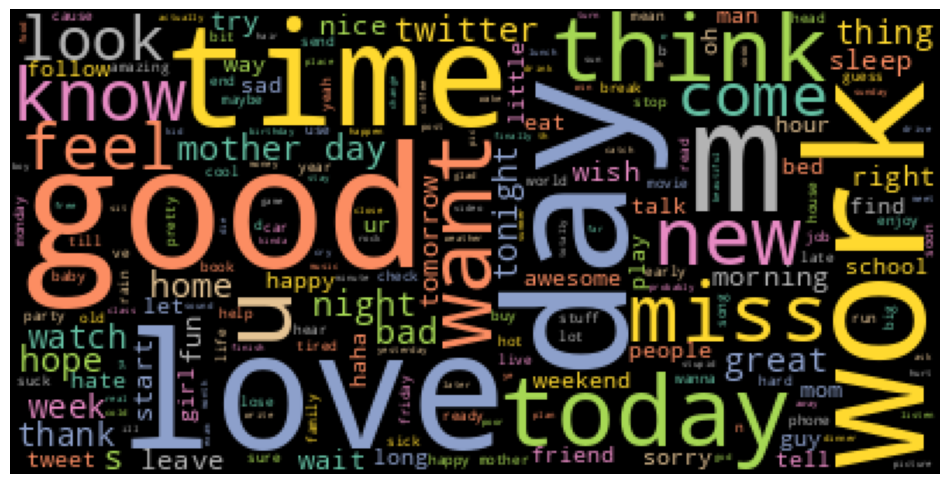

In [31]:
plt.figure(figsize = (12, 12), facecolor = None)
wc=WordCloud(colormap='Set2').generate(final_text)
plt.imshow(wc)
plt.axis("off")
plt.show()

## A Single function for pre-processing

In [32]:
def pre_processing(input_data, text_col):
    input_data["text_col_clean"]=input_data[text_col].apply(lambda x:str(x).lower())  # lowecase conversion
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:[expanded_form(t) for t in str(x).split()])  # Tokenization or expansion of contractions
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:[t for t in x if t not in spacy_stopwords ])  # Removing Stopwords
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:clean_with_re(x))  # Cleaning with regex (removing punctuations, URLs, digits)
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:" ".join([t.lemma_ for t in spacy_model(str(x))if t.lemma_ !="-PRON-" ]))  # Lemmatization [if t.lemma_ !="-PRON-" to avoid pronouns : used in older versions of spacy]
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:[t for t in str(x).split() if t not in spacy_stopwords ]) # Removing stopwords after lemmatization
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x: " ".join(x) )  # Final joining of tokens to form cleaned text
    print(input_data[[text_col,"text_col_clean"]])

In [33]:
pre_processing(input_data=twitter_data, text_col="raw_tweet")

                                               raw_tweet  \
0                    I`d have responded, if I were going   
1          Sooo SAD I will miss you here in San Diego!!!   
2                              my boss is bullying me...   
3                         what interview! leave me alone   
4       Sons of ****, why couldn`t they put them on t...   
...                                                  ...   
27476   wish we could come see u on Denver  husband l...   
27477   I`ve wondered about rake to.  The client has ...   
27478   Yay good for both of you. Enjoy the break - y...   
27479                         But it was worth it  ****.   
27480     All this flirting going on - The ATG smiles...   

                                          text_col_clean  
0                                              I respond  
1                                sooo sad miss san diego  
2                                           boss bully I  
3                                        in

## Document Term Matrix

Converting clean text data to numerical form

In [34]:
from sklearn.feature_extraction.text import CountVectorizer

countvec1 = CountVectorizer(min_df= 5) # keep only words having minimum word freq=5
dtm_v1 = pd.DataFrame(countvec1.fit_transform(twitter_data['Final_Cleaned_Tweet_tokens']).toarray(), columns=countvec1.get_feature_names_out(), index=None)
print(dtm_v1.shape)
dtm_v1

(27481, 3468)


,aaaah,aah,abandon,ability,abit,able,absolutely,abt,ac,academy,...,yum,yummy,yup,zac,zealand,zero,zombie,zone,zoo,ï½
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27476,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27477,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27478,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27479,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
